3. Business Analysis
In this phase, key business metrics are analyzed to identify improvement opportunities and answer the proposed business questions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/superstore_clean.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015


Sales and Profit by Category

In [2]:
df.groupby("Category")[["Sales","Profit"]].sum().sort_values("Sales", ascending=False)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


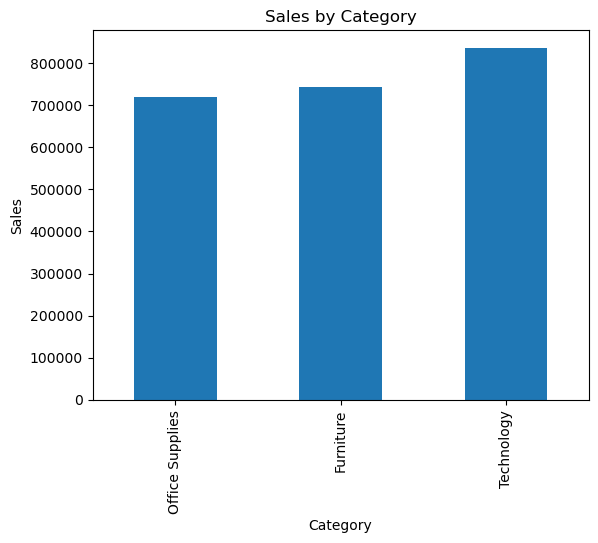

In [3]:
df.groupby("Category")["Sales"].sum().sort_values().plot(
    kind="bar"
)

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

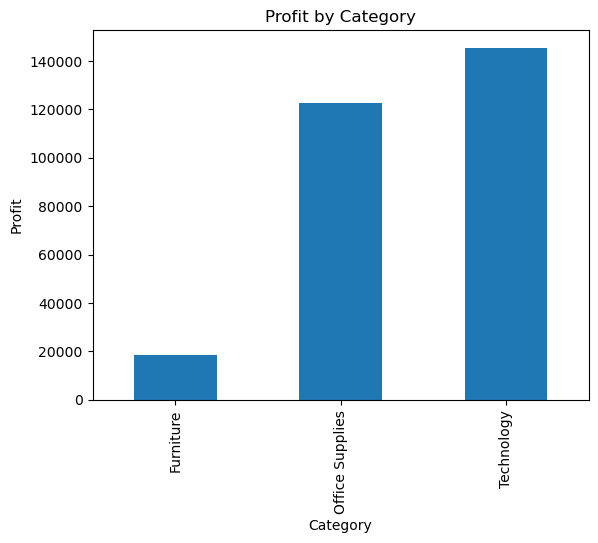

In [4]:
df.groupby("Category")["Profit"].sum().sort_values().plot(
    kind="bar"
)

plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

Category Analysis

Technology is the category with the highest sales and profit.

Furniture generates a high sales volume but significantly lower profit, indicating lower profitability.

Profitability by Category

In [5]:
category_analysis = df.groupby("Category")[["Sales","Profit"]].sum()

category_analysis["Profit_Margin"] = (
    category_analysis["Profit"] /
    category_analysis["Sales"]
) * 100

category_analysis.sort_values(
    "Profit_Margin",
    ascending=False
)

,Sales,Profit,Profit_Margin
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


Profit Margin by Category

Technology and Office Supplies have the highest profit margins.

Furniture has the lowest margin and may require a review of pricing or discount strategies.

Profit by Sub-Category

In [6]:
df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

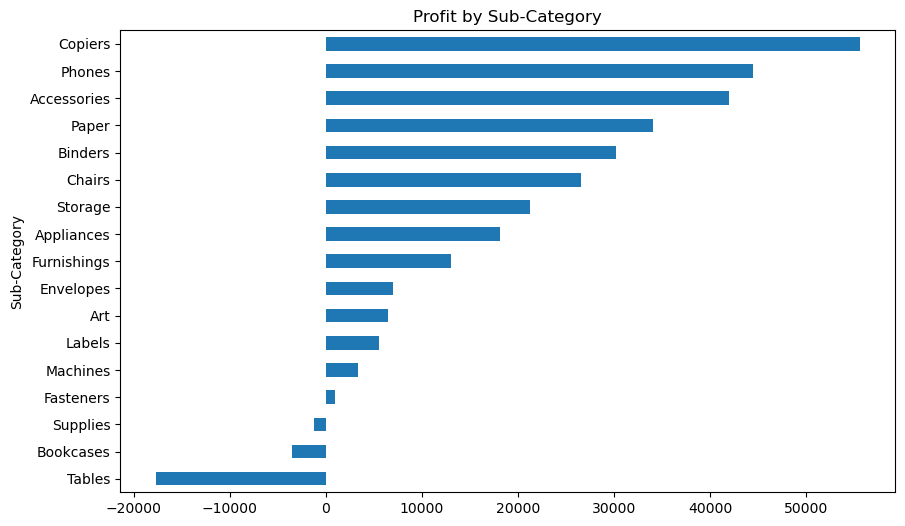

In [7]:
df.groupby("Sub-Category")["Profit"].sum().sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Profit by Sub-Category")
plt.show()

Sub-Category Analysis

Copiers is the most profitable sub-category.

Tables and Bookcases generate negative profit, indicating potential profitability issues.

Sales Evolution

In [8]:
df.groupby("Year")["Sales"].sum()

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

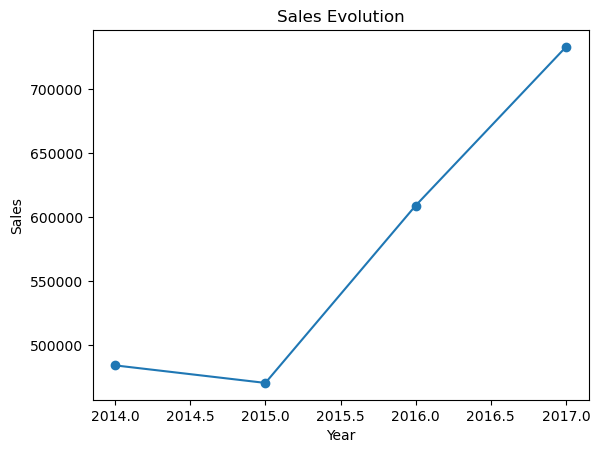

In [9]:
df.groupby("Year")["Sales"].sum().plot(
    kind="line",
    marker="o"
)

plt.title("Sales Evolution")
plt.ylabel("Sales")
plt.show()

Time Trend Analysis

Sales show an upward trend during the analyzed period.

2017 recorded the highest sales volume.

Impact of Discounts

In [10]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

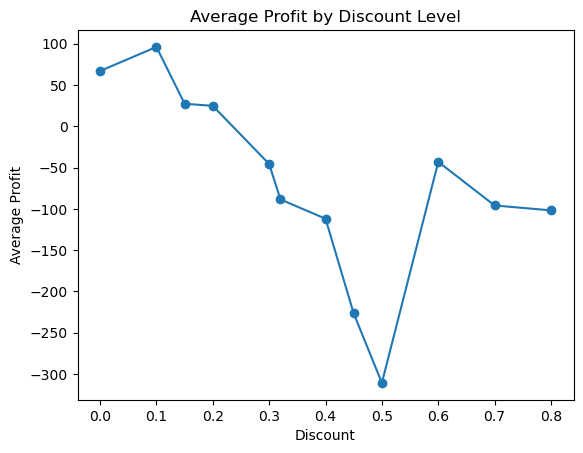

In [11]:
discount_profit.plot(
    kind="line",
    marker="o"
)

plt.title("Average Profit by Discount Level")
plt.ylabel("Average Profit")
plt.show()

Impact of Discounts

Low discount levels maintain positive profitability.

From around a 30% discount, average profit becomes negative.

High discount levels appear to negatively impact profitability.

Regional Analysis

In [12]:
region_analysis = df.groupby("Region")[["Sales","Profit"]].sum()

region_analysis["Profit_Margin"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"]
) * 100

region_analysis.sort_values(
    "Profit_Margin",
    ascending=False
)

,Sales,Profit,Profit_Margin
Region,,,
West,725457.8245,108418.4489,14.944831
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
Central,501239.8908,39706.3625,7.921629


Regional Analysis

The West region has the highest profit margin.

The Central region has the lowest margin and may offer opportunities for improvement.

Customer Segments

In [13]:
df.groupby("Segment")[["Sales","Profit"]].sum().sort_values(
    "Sales",
    ascending=False
)

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


Customer Segments

Consumer is the segment that generates the highest sales and profit.

Corporate and Home Office represent smaller business volumes.

Conclusions

• Technology achieves the best sales and profit performance.

• Furniture shows profitability challenges.

• Tables and Bookcases generate losses.

• Sales increased steadily throughout the analyzed period.

• High discount levels significantly reduce profitability.

• The West region delivers the strongest business performance.